# Generate Image Prompt in Python 



In [ ]:
import os
import requests
import gradio as gr
from dotenv import load_dotenv
from openai import OpenAI
from IPython.display import Markdown, display
import datetime
import re

In [ ]:
load_dotenv(override=True)
openai_api_key = os.getenv('OPENAI_API_KEY')
anthropic_api_key = os.getenv('ANTHROPIC_API_KEY')
google_api_key = os.getenv('GOOGLE_API_KEY')
deepseek_api_key = os.getenv('DEEPSEEK_API_KEY')
groq_api_key = os.getenv('GROQ_API_KEY')
grok_api_key = os.getenv('GROK_API_KEY')
openrouter_api_key = os.getenv('OPENROUTER_API_KEY')

if openai_api_key:
    print(f"OpenAI API Key exists and begins {openai_api_key[:8]}")
else:
    print("OpenAI API Key not set")
    
if anthropic_api_key:
    print(f"Anthropic API Key exists and begins {anthropic_api_key[:7]}")
else:
    print("Anthropic API Key not set (and this is optional)")

if google_api_key:
    print(f"Google API Key exists and begins {google_api_key[:2]}")
else:
    print("Google API Key not set (and this is optional)")

if deepseek_api_key:
    print(f"DeepSeek API Key exists and begins {deepseek_api_key[:3]}")
else:
    print("DeepSeek API Key not set (and this is optional)")

if groq_api_key:
    print(f"Groq API Key exists and begins {groq_api_key[:4]}")
else:
    print("Groq API Key not set (and this is optional)")

if grok_api_key:
    print(f"Grok API Key exists and begins {grok_api_key[:4]}")
else:
    print("Grok API Key not set (and this is optional)")

if openrouter_api_key:
    print(f"OpenRouter API Key exists and begins {openrouter_api_key[:3]}")
else:
    print("OpenRouter API Key not set (and this is optional)")


In [ ]:
openai = OpenAI()

# For Gemini, DeepSeek and Groq, we can use the OpenAI python client
# Because Google and DeepSeek have endpoints compatible with OpenAI
# And OpenAI allows you to change the base_url

anthropic_url = "https://api.anthropic.com/v1/"
gemini_url = "https://generativelanguage.googleapis.com/v1beta/openai/"
deepseek_url = "https://api.deepseek.com"
groq_url = "https://api.groq.com/openai/v1"
grok_url = "https://api.x.ai/v1"
openrouter_url = "https://openrouter.ai/api/v1"
ollama_url = "http://localhost:11434/v1"

anthropic = OpenAI(api_key=anthropic_api_key, base_url=anthropic_url)
gemini = OpenAI(api_key=google_api_key, base_url=gemini_url)
deepseek = OpenAI(api_key=deepseek_api_key, base_url=deepseek_url)
groq = OpenAI(api_key=groq_api_key, base_url=groq_url)
grok = OpenAI(api_key=grok_api_key, base_url=grok_url)
openrouter = OpenAI(base_url=openrouter_url, api_key=openrouter_api_key)
ollama = OpenAI(api_key="ollama", base_url=ollama_url)

outputDir="G:/GenerativeAIOutput/pythonSD"

In [ ]:
llama32="llama3.2"
mistralThinker="hf.co/mradermacher/MistralThinker-v1.1-i1-GGUF:Q4_K_M"
qwen3coder30b="qwen3-coder:30b"
gemma3_4b="gemma3:4b"
gemma3_12b="gemma3:12b"
gptOss20b="gpt-oss:20b"

In [ ]:

MODEL=gemma3_4b
REPAIR_MODEL=gemma3_4b
system_message = "You are a helpful chatbot who generates stable diffusion image prompts based on the text from a story.  You will be given story text or poem.  For each paragraph of the story (or stanza of a poem), generate a concise stable diffusion prompt that captures the essence of the paragraph in vivid detail.  Use descriptive language and include artistic styles or techniques where appropriate.  If a paragraph does not contain any descriptive elements then combine it with the next text section and analyze both paragraphs together. It is very important to maintain consistent character appearances and settings across all prompts.  If a character is described as having specific features or clothing in one paragraph, ensure those details are reflected in all subsequent prompts involving that character. Output in a JSON array of objects.  The JSON must be valid and the only output. Double quotes are for the json structure only, in describing the key:value pairs.  Within the text content there should be no double quotes.  All double quotes in the content have been replaced with single quotes, and these should not be changed.  Within the json array, each array object contains exactly 2 fields: storyline with the exact and complete wording of the story text, and its related prompt.  The enclosing array should have one starting bracket [ and one ending bracket ].  As in the following example, JSON should be your only output - no extra markdown or extraneous information. <Example> [ {'storyline':'Massachusetts looked up from her algebra. She was the head of the school. She was rosy and placid as the apple she was generally eating when not in class. Apples and algebra were the things she cared most about in school life.','prompt':'A young teacher, Massachusetts, sits at a classroom desk, surrounded by textbooks and an apple, her expression serene and studious'}, {'storyline':'Oh, dear oh, dear Its snowing,Hurrah hurrah Its snowing','prompt':'A cluster of smiling students excitedly shout, Its snowing, their faces aglow with anticipation and winter wonder.'}...  ]   </Example>"


In [ ]:
def currentFormattedTime():
    return datetime.datetime.now().strftime("%Y-%m-%d_%H-%M-%S")

In [ ]:
import json
def check_json_valid(json_string):
    try:
        json_object = json.loads(json_string)
    except json.JSONDecodeError as e:
        print("Invalid JSON syntax:", e)
        return False
    return True

In [ ]:
def clean_json_string(json_string):
    json_string = json_string.strip()
    pattern = r"```json\n?|```"
    cleaned_string = re.sub(pattern, "", json_string)
    return cleaned_string   

In [ ]:
def try_fix_json(json_string):

    fixer_message = f"The following JSON string may be malformed.  Please fix it so that it is valid JSON. Only return the fixed JSON string and nothing else.  Here is the json to fix: '''{json_string}'''"

    messages = [{"role": "system", "content": "You are a JSON repair robot.  Your job is to fix malformed json."}] + [{"role": "user", "content": fixer_message}]

    response = ollama.chat.completions.create(model=REPAIR_MODEL, messages=messages)
    result = response.choices[0].message.content
    return (clean_json_string(result))

In [ ]:
example_story= [
{
"storyline": "A cluster of smiling students excitedly shout, Its snowing, their faces aglow with anticipation and winter wonder.",
"prompt": "A group of happy students, Virginia, Maine, and Rhode Island, stand under a colorful umbrella in the school courtyard, Their voices echoing joyful excitement on a snowy day; snowflakes gently fall around them"
},
{
"storyline": "Oh, dear! oh, dear! It's snowing! Hurrah! hurrah! Its snowing!",
"prompt": "An animated cluster of students rush to the school courtyard in front of Massachusetts, who sits at her desk as she gazes curiously into the morning. The scene is a vibrant and colorful celebration."
},
{
"storyline": "Massachusetts looked up from her algebra. She was the head of the school. She was rosy and placid as the apple she was generally eating when not in class. Apples and algebra were the things she cared most about in school life.",
"prompt": "In a serene drawing room, Massachusetts sits at her spacious wooden desk in front of an intricately carved farder adorned her face with hues typical to springtime. The backdrop shows the calm morning after snow; she takes apple from it. Apple leaves have just begun to change colors and there is a few scattered white flakes outside."
},
{
"storyline": "Whence come these varying cries? she said, taking her feet off the fender and trying to be interested, though her thoughts went on with a 1/6 b  etc.",
"prompt": "Miss Wayland has the desk where Massachusetts sits while still doing her algebra in front of a beautiful window. She observes as the school staff go about their school day routine, students from nearby classrooms shout excitedly"
},
{
"storyline": "Oh, Virginia is grumbling because it is snowing, and Maine is feeling happy over it, that's all! said Rhode Island, the smallest girl in Miss Wayland's school.",
"prompt": "Miss Wayland observes as Rhode island comes closer to her and begins to teach a group of students in front of an old wooden desks. The setting has been captured amidst an atmosphere of learning with chalk on chalkboard covered at edges, books stacked neatly beside classrooms."
}
]





In [ ]:
# following https://civitai.com/articles/4090/make-a-stable-diffusion-easy-interface-with-python
# Import the libraries

import requests
import json
from PIL import Image
from io import BytesIO
import base64
import datetime



In [ ]:
textToImg_url = "http://127.0.0.1:7860/sdapi/v1/txt2img"
outputDir = "G:/GenerativeAIOutput/pythonSD"
model_juggernaut = "juggernautXL_v8Rundiffusion.safetensors [aeb7e9e689]"
default_negative_prompt = "blurry, low quality, bad anatomy"

In [ ]:
# Define the function to call the API
# Must start Automatic 1111 web server before running this code
def call_api(prompt, negative_prompt):
    # Define the URL of the API endpoint
    url = textToImg_url
    data = {
        "prompt": prompt,
        "negative_prompt": default_negative_prompt + negative_prompt,
        "steps": 30, #default is 20
        "sampler_name": "DPM++ 2M Karras", #default is Euler 
        "cfg_scale": 7,
        "seed": -1, # -1 for random seed
        "width": 1024, #default is 512
        "height": 1024,
        "override_settings": {
            "sd_model_checkpoint": model_juggernaut
         }
    }

   # Convert the data to JSON format
    json_data = json.dumps(data)

    # Set the headers for the request
    headers = {'Content-Type': 'application/json'}

    # Send the POST request to the API
    response = requests.post(url, data=json_data, headers=headers)

    # Check if the request was successful (status code 200)
    if response.status_code == 200:
       # Decode the JSON response
        json_response = response.json()

        # Extract the base64 image data from the response
        image_data = json_response.get('images', [''])[0]

        # Decode the base64 image data
        image_bytes = base64.b64decode(image_data)

        # Open the image using PIL
        image = Image.open(BytesIO(image_bytes))
        current_time = datetime.datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
        filename =f"{outputDir}/{currentFormattedTime()}.jpg"
        image.save(filename),filename  # Save the image to a file
        return image, filename
    else:
        # Return an error message if the request was not successful
        return "Error:", response.status_code


In [ ]:
def generate_images_from_story(story_json):
    for index,story in enumerate(story_json):
        prompt = story_json[index]['prompt']
        storyline = story_json[index]['storyline']
        print("Generating image for storyline:", storyline)
        negative_prompt = "lowres, bad anatomy, error body parts, error hands and fingers, error legs and feet, error face, deformed, blurry, ugly"
        image, filename = call_api(prompt, negative_prompt)
        story_json[index]['imagePath']=filename
        display(Markdown(f"**Storyline:** {storyline}"))
        display(image)
    with open(f'{outputDir}/{currentFormattedTime()}.json', 'w') as f:
        json.dump(story_json, f)

In [ ]:
example_raven_json=[
  {
    "storyline": "I pondered, weak and weary,\nOver many a quaint and curious volume of forgotten lore—",
    "prompt": "A lone figure, slumped over an old book, surrounded by dusty tomes, looks worn and tired, with a haze of curiosity in their eyes"
  },
  {
    "storyline": "The bleak December night hung heavy outside my chamber door; each dying ember wreathed its ghost upon the floor.",
    "prompt": "A dark, moonless night scene: frosty chamber window, a few candles glow faintly on the floor, surrounded by shadows."
  },
  {
    "storyline": "I wished the morrow;—vainly I had sought to borrow\nFrom my books surcease of sorrow—sorrow for the lost Lenore—",
    "prompt": "A dimly lit library with shelves of old books; a single, flickering candle casts eerie shadows on the walls."
  },
  {
    "storyline": "Eagerly I wished the morrow;—vainly I had sought to borrow\nFrom my books surcease of sorrow—sorrow for the lost Lenore;",
    "prompt": "A desolate, midnight chamber with a single bird perched on a bust of Pallas."
  },
  {
    "storyline": "Quoth the Raven Nevermore.",
    "prompt": "A black bird perches menacingly on a bust of Pallas in front of an empty chamber door, its eyes glowing with an otherworldly intensity"
  },
  {
    "storyline": "I sat engaged in guessing, but no syllable expressing\nTo the fowl whose fiery eyes now burned into my bosom’s core;",
    "prompt": "A single bird, with its wings spread wide, perched in front of a human figure, who looks up with a mixture of desire and sorrow"
  },
  {
    "storyline": "She shall press, ah, nevermore!",
    "prompt": "The chamber door slowly creaks shut behind a female figure, as the Raven watches from outside"
  }
]


#generate_images_from_story(example_raven_json)


In [ ]:
def save_json_to_file(json_string, filename):
    with open(filename, 'w', encoding='utf-8') as f:
        json.dump(json_string, f, ensure_ascii=False, indent=4)

In [ ]:
def chat(message, history):
    history = [{"role":h["role"], "content":h["content"]} for h in history]
    relevant_system_message = system_message
    message = message.encode("ascii", "ignore").decode('ascii') #.decode("utf-8")
    #display(Markdown(message))
    #message = message.replace('"', '\"')
    # if 'belt' in message.lower():
    #     relevant_system_message += " The store does not sell belts; if you are asked for belts, be sure to point out other items on sale."
    
    messages = [{"role": "system", "content": relevant_system_message}] + history + [{"role": "user", "content": message}]

    response = ollama.chat.completions.create(model=MODEL, messages=messages, stream=False)

    result = response.choices[0].message.content
    result = clean_json_string(result)

   # result = result.replace(/```json\n?|```/g, '')
    # result = json.dumps(result)
   # print(f"char1-5: {result[:20]}")
   # print(f"char last: {result[-5:]}")

    display(Markdown(result))
    # generate_images_from_story(json.load(result))
    # return result

    isValidJson = check_json_valid(result)
    nAttempts=0
    while (isValidJson==False):
        nAttempts += 1
        print(f"Invalid JSON and trying fix - attempt #{nAttempts}")
        result = try_fix_json(result)
        isValidJson = check_json_valid(result)
        if ((isValidJson==False) and nAttempts>3):
            print("Fixes failed, could not create valid json.")
            return result
    try:
        jsonResult = json.loads(result) 
        #jsonResult.save(f"{outputDir}/{currentFormattedTime()}.json")
        generate_images_from_story(jsonResult)
    except Exception as e:
        print(f"Error saving JSON: {e}")
    return result

    # response = ""
    # for chunk in stream:
    #     response += chunk.choices[0].delta.content or ''
    #     yield response

**Storyline:** This I whispered, and an echo murmured back the word, Lenore! Merely this and nothing more.

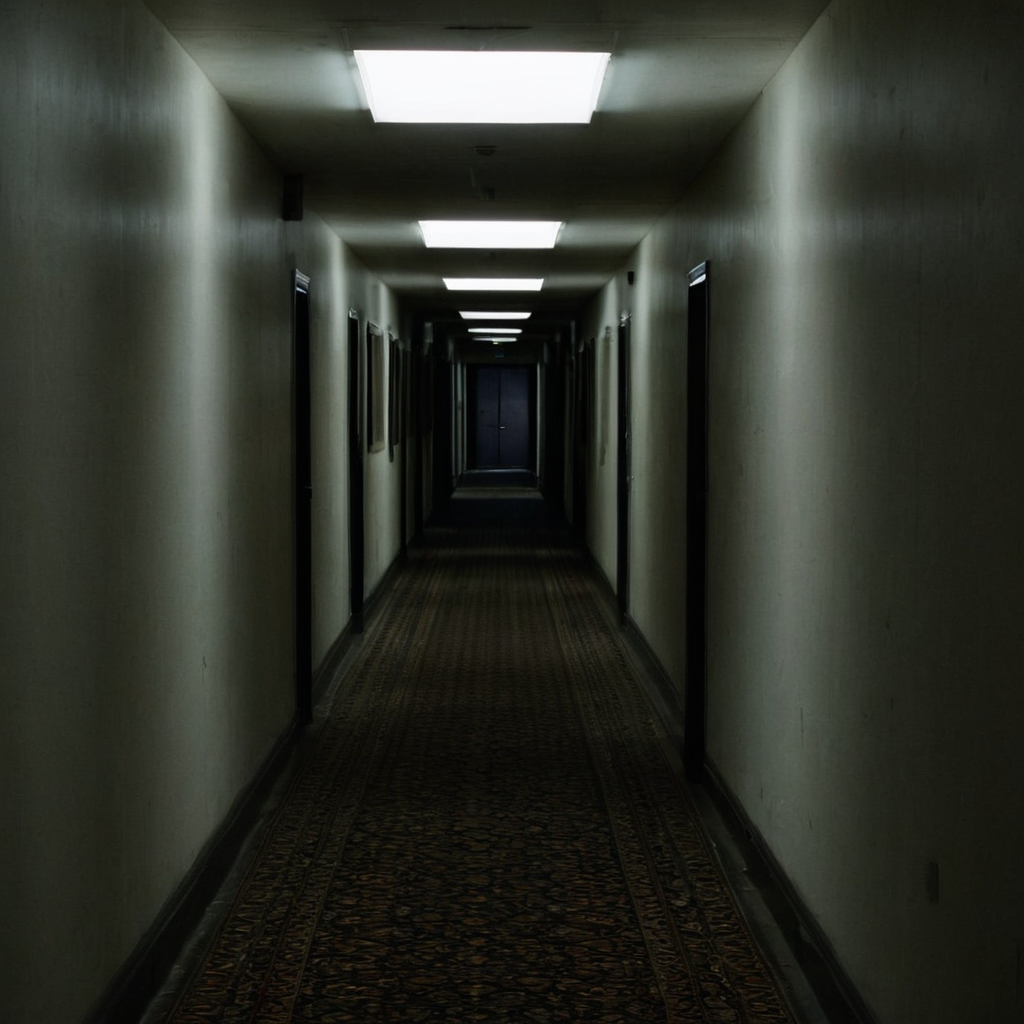

Generating image for storyline: Startled at the stillness broken by reply so aptly spoken, Doubtless, said I what it utters is its only stock and store Caught from some unhappy master whom unmerciful Disaster Followed fast and followed faster till his songs one burden bore


In [ ]:
gr.ChatInterface(fn=chat, type="messages").launch()